# Exploratory Data Analysis: Bondora Peer-to-Peer Lending

## Project Overview

This project presents a comprehensive exploratory data analysis (EDA) of the Bondora peer-to-peer lending dataset, containing over 409,000 loan records. The analysis employs descriptive statistics, data visualization, inferential hypothesis testing, and linear regression to examine the factors influencing loan approval, interest rate determination, and borrower risk profiles. The work demonstrates core data analytics competencies including data cleaning, statistical testing, visualization, and explanatory modeling.

**Dataset Source**: [Bondora P2P Loans - Kaggle](https://www.kaggle.com/datasets/marcobeyer/bondora-p2p-loans)

**Analysis Focus**: This project emphasizes exploratory and statistical analysis rather than advanced machine learning. The objective is to uncover actionable insights into lending patterns, risk pricing mechanisms, and demographic relationships within the platform.

## Project Scope and Methodology

This analysis employs a structured, multi-phase approach to understanding peer-to-peer lending dynamics:

1. **Data Cleaning and Preparation**: Load raw data, handle missing values, convert data types, and perform initial quality assurance.
2. **Descriptive Analysis**: Compute summary statistics and visualize distributions of key lending variables.
3. **Correlation Analysis**: Examine relationships between numeric variables to identify multicollinearity and associations.
4. **Inferential Statistics**: Conduct hypothesis tests to assess statistical significance of observed differences in borrowing patterns.
5. **Regression Modeling**: Develop linear regression models to quantify determinants of interest rates and loan approval amounts.
6. **Risk Assessment**: Identify high-risk borrower segments using multifactorial criteria.

Throughout the analysis, transparency regarding data limitations and methodological assumptions is maintained to ensure findings are appropriately qualified.

## Part 1: Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

### Step 1: Load and Prepare Data

The original Bondora dataset contains 97 variables across 409,951 loan observations. For analytical clarity and efficiency, we focus on 18 variables directly relevant to understanding loan characteristics, borrower profiles, and lending outcomes.

**Dataset Source**:
https://www.kaggle.com/datasets/marcobeyer/bondora-p2p-loans

**Data Volume**: 97 original columns, 409,951 unique loan records

### Selected Features

| Variable | Description |
|----------|-------------|
| `LoanId` | Unique identifier for each loan |
| `LoanDate` | Date when the loan was issued |
| `NewCreditCustomer` | Whether borrower is a new credit customer |
| `Age` | Age of borrower (years) |
| `Country` | Country of borrower residence |
| `Gender` | Borrower gender (0: Male, 1: Female, 2: Unknown) |
| `AppliedAmount` | Loan amount requested by borrower |
| `Amount` | Loan amount actually approved and disbursed |
| `Interest` | Annual interest rate on loan |
| `LoanDuration` | Loan term in months |
| `EmploymentDurationCurrentEmployer` | Years at current employer |
| `IncomeTotal` | Total annual income |
| `ExistingLiabilities` | Number of existing liabilities |
| `Rating` | Bondora credit rating (AA to HR) |
| `NoOfPreviousLoansBeforeLoan` | Count of prior loans |
| `AmountOfPreviousLoansBeforeLoan` | Total value of prior loans |
| `PreviousRepaymentsBeforeLoan` | Repayment history indicator |
| `Status` | Current loan status (e.g., Repaid, Current, Defaulted) |

In [ ]:
# Define relevant columns for analysis
cols = [
    'LoanId',
    'LoanDate',
    'NewCreditCustomer',
    'Age',
    'Country',
    'Gender',
    'AppliedAmount',
    'Amount',
    'Interest',
    'EmploymentDurationCurrentEmployer',
    'LoanDuration',
    'IncomeTotal',
    'ExistingLiabilities',
    'Rating',
    'NoOfPreviousLoansBeforeLoan',
    'AmountOfPreviousLoansBeforeLoan',
    'PreviousRepaymentsBeforeLoan',
    'Status'
]

### Step 2: Load Data and Initial Inspection

The dataset is loaded into a pandas DataFrame and examined for structure and integrity. Initial inspection includes reviewing data types, identifying missing values, and understanding variable distributions.

In [ ]:
df = pd.read_csv(
    "/kaggle/input/bondora-p2p-loans/LoanData.csv",
    usecols=cols,
    low_memory=False
)
df.head()

,LoanId,NewCreditCustomer,LoanDate,Age,Gender,Country,AppliedAmount,Amount,Interest,LoanDuration,EmploymentDurationCurrentEmployer,IncomeTotal,ExistingLiabilities,Rating,Status,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousRepaymentsBeforeLoan
0,D8EBF360-104C-420F-BEC9-000924E6EFC7,False,2022-09-09,27,1.0,EE,3189.0,3189.0,35.48,60,UpTo5Years,900.0,0,D,Current,1.0,3402.0,1161.57
1,C1A98DDA-5E20-429C-BBFF-0009A05354E0,False,2023-05-19,35,1.0,FI,4146.0,4146.0,19.86,60,UpTo5Years,3100.0,0,B,Late,1.0,518.0,525.21
2,9B0B252E-45B9-4172-8E2D-0014A8F18117,False,2024-02-03,23,0.0,EE,531.0,531.0,19.52,60,UpTo5Years,1700.0,0,B,Current,3.0,1593.0,631.35
3,66AE108B-532B-4BB3-BAB7-0019A46412C1,False,2016-03-23,53,1.0,EE,2125.0,2125.0,20.97,60,MoreThan5Years,354.0,8,C,Repaid,1.0,500.0,590.95
4,C7EA512A-465D-4043-A9F2-001B14C3C14E,False,2023-09-26,43,0.0,FI,414.0,414.0,19.89,108,Other,1200.0,0,D,Late,5.0,11198.0,1176.22


### Step 3: Data Cleaning and Preparation

In [5]:
# Convert LoanDate to DateTime 
df["LoanDate"] = pd.to_datetime(df["LoanDate"], format="mixed")

In [ ]:
# Handle missing values strategically
df['EmploymentDurationCurrentEmployer'] = (
    df['EmploymentDurationCurrentEmployer'].fillna('Unknown')
)

# Fill numeric borrowing history variables with 0 (represents no prior activity)
df['NoOfPreviousLoansBeforeLoan'] = df['NoOfPreviousLoansBeforeLoan'].fillna(0)
df['AmountOfPreviousLoansBeforeLoan'] = df['AmountOfPreviousLoansBeforeLoan'].fillna(0)
df['PreviousRepaymentsBeforeLoan'] = df['PreviousRepaymentsBeforeLoan'].fillna(0)

# Fill gender missing values with category 2 (Unknown)
df['Gender'] = df['Gender'].fillna(2)

### Missing Value Strategy

A principled approach to missing data was employed:

- **Categorical Variables** (Employment Duration): Missing values filled with "Unknown" category to retain observations while preserving interpretability.
- **Numeric History Variables**: Filled with zeros, reflecting new borrowers with no prior loan activity.
- **Credit Ratings**: Not imputed; instead, excluded selectively from rating-specific analyses to avoid contamination.
- **Gender**: Missing values coded as category 2 ("Unknown") to maintain sample integrity.

This strategy balances data preservation with analytical rigor.

In [ ]:
# Verify missing values after cleaning
df.isna().sum()

LoanId                                  0
NewCreditCustomer                       0
LoanDate                                0
Age                                     0
Gender                                  0
Country                                 0
AppliedAmount                           0
Amount                                  0
Interest                                0
LoanDuration                            0
EmploymentDurationCurrentEmployer       0
IncomeTotal                             0
ExistingLiabilities                     0
Rating                               2733
Status                                  0
NoOfPreviousLoansBeforeLoan             0
AmountOfPreviousLoansBeforeLoan         0
PreviousRepaymentsBeforeLoan            0
dtype: int64

Missing values have been appropriately handled. Proceeding to indexing and descriptive analysis.

In [ ]:
# Set LoanId as the index
df.set_index("LoanId", inplace=True)
df.index.name

'LoanId'

## Part 2: Descriptive Analysis

### 2.1 Summary Statistics

Descriptive statistics provide foundational insight into the distribution, central tendency, and variability of key lending variables. These metrics establish baseline understanding before proceeding to hypothesis testing and modeling.

In [9]:
df.describe()

,LoanDate,Age,Gender,AppliedAmount,Amount,Interest,LoanDuration,IncomeTotal,ExistingLiabilities,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousRepaymentsBeforeLoan
count,409951,409951.000000,409951.000000,409951.000000,409951.000000,409951.000000,409951.000000,4.099510e+05,409951.000000,409951.000000,409951.000000,409951.000000
mean,2021-04-08 04:41:37.434083328,40.313133,0.482636,2557.140958,2489.086937,26.618567,50.002961,2.174318e+03,2.710331,1.975829,3838.384003,735.070309
min,2009-02-28 00:00:00,0.000000,0.000000,10.000000,6.390000,2.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,2019-08-15 00:00:00,31.000000,0.000000,740.000000,726.000000,18.860000,36.000000,1.100000e+03,1.000000,0.000000,0.000000,0.000000
50%,2021-12-12 00:00:00,39.000000,0.000000,2125.000000,2080.000000,20.070000,60.000000,1.700000e+03,2.000000,1.000000,1165.000000,85.860000
75%,2023-06-01 00:00:00,49.000000,1.000000,4146.000000,4146.000000,31.350000,60.000000,2.500000e+03,4.000000,3.000000,5731.000000,640.700000
max,2024-08-22 00:00:00,77.000000,2.000000,15948.000000,15948.000000,264.310000,120.000000,1.012019e+06,62.000000,86.000000,119983.000000,34077.420000
std,NaN,12.170074,0.576941,2117.097563,2037.360500,17.730200,18.216830,9.359534e+03,3.026652,3.191893,5653.365263,1599.414623


### Key Observations from Summary Statistics

- **Sample Size**: 409,951 unique loans analyzed
- **Borrower Age**: Median age of 40 years, ranging from very young to elderly borrowers (outliers present)
- **Loan Amounts**: Median of 2,080 EUR, with substantial right-skew indicating most loans are modest while some are considerably larger
- **Loan Duration**: Commonly 36–60 months, indicating standard medium-term lending products
- **Income**: Right-skewed distribution with extreme outliers, typical of financial datasets
- **Interest Rates**: Variable across ratings; right-skewed reflecting risk-based pricing

**Data Quality Notes**: Minor anomalies observed (extreme ages, implausibly high incomes) are acknowledged and retained to preserve sample integrity while recognizing their outlier status.

### 2.2 Distribution Visualizations

The following visualizations illustrate the distributions and key relationships among lending variables.

#### 1. Loan Amount Distribution

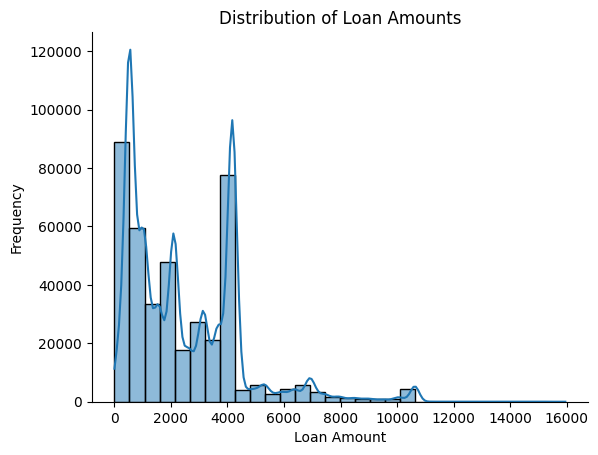

In [ ]:
# Histogram of Loan Amounts
sns.histplot(df['Amount'], bins=30, kde=True, edgecolor='black')
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount (EUR)")
plt.ylabel("Frequency")
sns.despine()
plt.show()

The distribution of loan amounts exhibits pronounced positive skewness, with the majority of loans concentrated in the lower range (median ≈ 2,080 EUR). The extended right tail reflects a minority of larger loans, typical of consumer lending markets where most borrowers seek modest amounts while a subset requires larger financing. This heterogeneity in borrower demand reflects diverse use cases and financial circumstances across the borrower population.

#### 2. Interest Rates by Credit Rating

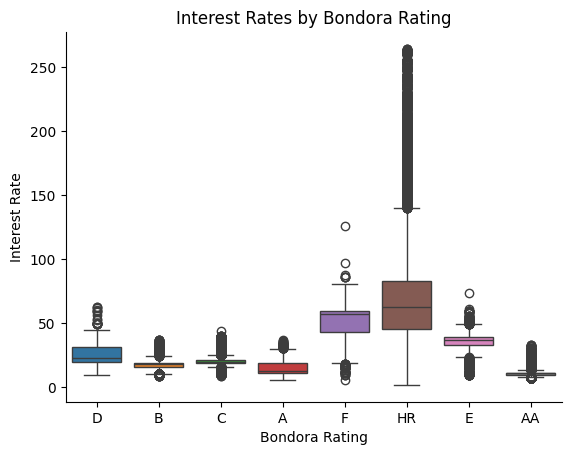

In [ ]:
# Boxplot of Interest Rates by Bondora Rating
df_plot = df.dropna(subset=['Rating'])

sns.boxplot(data=df_plot, x='Rating', y='Interest', hue='Rating')
plt.title('Interest Rates by Bondora Rating')
plt.xlabel('Bondora Rating')
plt.ylabel('Interest Rate (%)')
sns.despine()
plt.show()

A clear inverse relationship exists between credit ratings and interest rates. Borrowers with lower ratings (e.g., HR, F) receive substantially higher interest rates with greater variance, while higher-rated borrowers (A, AA) receive lower rates with tighter distributions. This monotonic pattern reflects risk-based pricing: lenders charge higher rates to compensate for elevated default risk on lower-quality credits. Outliers within rating categories suggest loan-specific factors beyond ratings (e.g., loan purpose, collateral) influence final pricing.

#### 3. Income Distribution by Gender

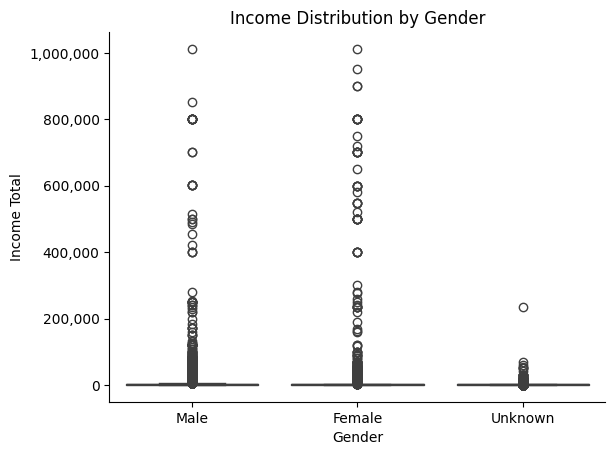

In [ ]:
# Boxplot of Income Distribution by Gender
import matplotlib.ticker as mtick

ax = sns.boxplot(data=df, x='Gender', y='IncomeTotal')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_title('Income Distribution by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Income (EUR)')
ax.xaxis.set_ticklabels(['Male', 'Female', 'Unknown'])
sns.despine()
plt.show()

Income distributions across gender categories exhibit comparable median values with right-skewness in all groups. The similarity in central location suggests that borrower income is not strongly differentiated by gender within the Bondora platform. However, the presence of outliers across all gender categories indicates that high-income earners exist in each group. Further analysis would be needed to assess whether income disparities exist at the tails of the distribution.

#### 4. Geographic Distribution of Loans

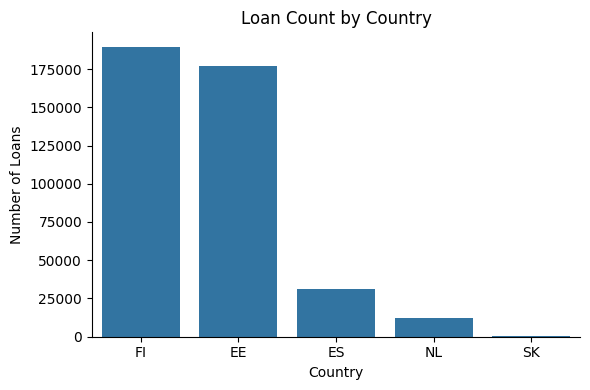

In [ ]:
# Countplot of Loans by Country
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Country', order=df['Country'].value_counts().index)
plt.title('Loan Count by Country')
plt.xlabel('Country')
plt.ylabel('Number of Loans')
plt.xticks(rotation=0)
plt.tight_layout()
sns.despine()
plt.show()

The geographic distribution reveals marked concentration in Estonia (EE) and Finland (FI), which together account for the vast majority of loans. This concentration reflects Bondora's operational presence and market penetration in Northern Europe. The stark disparity in loan volumes across countries suggests variations in adoption rates of peer-to-peer lending, differences in local credit market conditions, and regulatory environments that may either facilitate or constrain platform growth.

#### 5. Interest Rates by Loan Duration

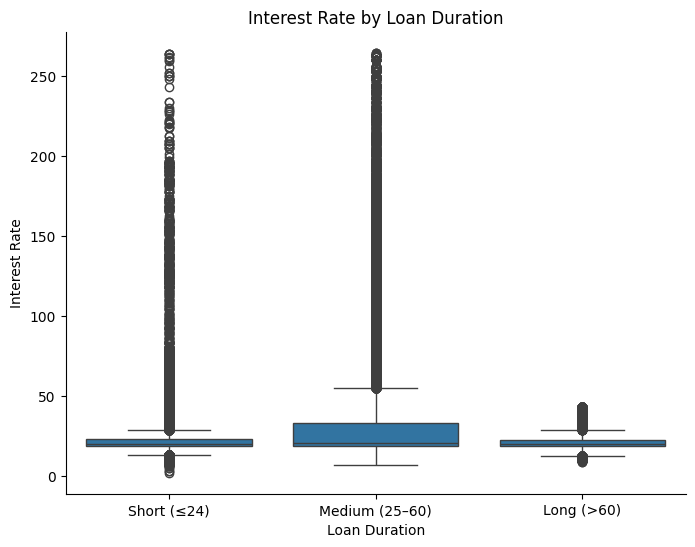

In [ ]:
# Create duration categories and visualize
bins = [0, 24, 60, np.inf]
labels = ['Short (≤24)', 'Medium (25–60)', 'Long (>60)']
df['LoanDurationGroup'] = pd.cut(df['LoanDuration'], bins=bins, labels=labels, right=True)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='LoanDurationGroup', y='Interest', order=labels)
plt.title('Interest Rate by Loan Duration Category')
plt.xlabel('Loan Duration')
plt.ylabel('Interest Rate (%)')
sns.despine()
plt.show()

Interest rate distributions vary across loan duration categories. Short-term loans (≤24 months) and long-term loans (>60 months) exhibit comparable median rates with lower variability, while medium-term loans (25–60 months) show slightly elevated median rates with greater dispersion. This pattern may reflect the "hump" in duration risk: very short loans are lower risk due to rapid maturity, while very long loans may serve a distinct market segment. Mid-term loans, the most common category, exhibit more heterogeneous pricing. Outliers in short and medium categories indicate that individual borrower characteristics override standard duration-based pricing for some loans.

#### 6. Loan Status Distribution

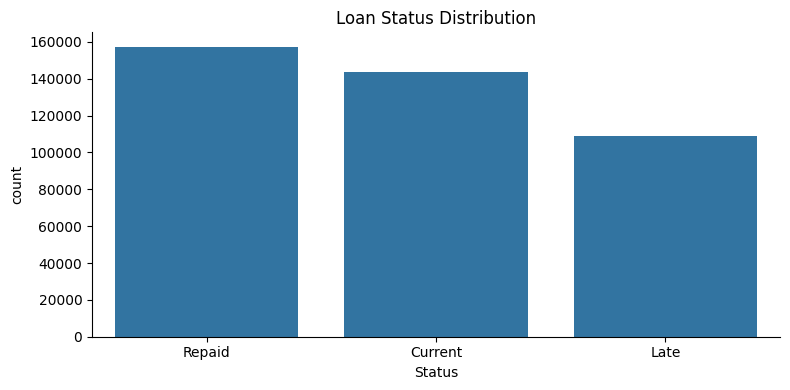

In [ ]:
# Countplot of Loan Status
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index)
plt.title('Loan Status Distribution')
plt.ylabel('Count')
sns.despine()
plt.tight_layout()
plt.show()

The loan status distribution is heavily dominated by "Repaid" loans, with "Current" (active) loans comprising a secondary portion. The skewed composition toward completed repayments reflects either an aged dataset containing historical loans that have reached maturity, or relatively low default incidence on the platform. To fully assess portfolio credit risk, detailed analysis of default-related status categories would be required. This distribution limits our ability to assess default rates and loss severity based on this dataset alone.

### 2.3 Correlation Analysis

Correlation analysis examines relationships among numeric variables, identifying potential multicollinearity and informing variable selection for subsequent regression modeling.

In [ ]:
# Compute correlation matrix for key numeric variables
num_cols = [
    'Age', 'AppliedAmount', 'Amount', 'Interest',
    'LoanDuration', 'IncomeTotal',
    'ExistingLiabilities', 'NoOfPreviousLoansBeforeLoan', 'PreviousRepaymentsBeforeLoan'
]

corr = df[num_cols].corr()

# Focus on correlations with loan amount
print("Correlations with Loan Amount:")
print(corr['Amount'].sort_values(ascending=False))

Age                             0.101613
AppliedAmount                   0.964325
Amount                          1.000000
Interest                       -0.038070
LoanDuration                    0.239139
IncomeTotal                     0.013571
ExistingLiabilities            -0.146102
NoOfPreviousLoansBeforeLoan    -0.188042
PreviousRepaymentsBeforeLoan    0.032347
Name: Amount, dtype: float64


**Key Correlation Findings**:

- **Applied Amount ↔ Loan Amount** (r = 0.96): Near-perfect positive correlation indicates that approved loan amounts closely track borrower requests. This suggests a high approval rate or pre-screening process that aligns approvals with applications.
  
- **Interest Rate ↔ Loan Amount** (r ≈ -0.03): Weak negative correlation suggests larger loans are marginally associated with lower interest rates, possibly reflecting better creditworthiness or reduced relative funding costs for larger amounts.

- **Income ↔ Loan Amount** (r ≈ 0.014): Negligible correlation indicates loan size is not strongly driven by borrower income, suggesting underwriting incorporates diverse criteria beyond income alone.

- **Age, Duration, Liabilities**: Weak correlations with loan amounts indicate these demographic and loan characteristics operate largely independently as pricing factors.

This weak to moderate correlation structure suggests low multicollinearity, which is favorable for regression modeling.

#### Correlation Heatmap

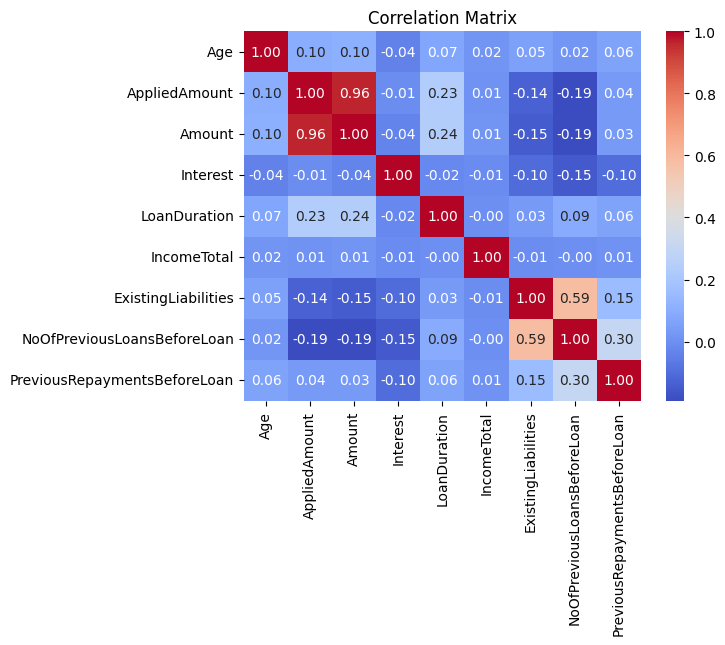

In [ ]:
# Create correlation heatmap
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Numeric Variables')
plt.tight_layout()
plt.show()

The correlation heatmap visualizes the complete interdependence structure. The strongest relationships exist between applied and received amounts, confirming loan fulfillment consistency. Interest rates exhibit modest correlations with loan duration and other variables. The predominantly weak correlations across demographic and financial variables suggest that lending decisions incorporate multiple independent factors rather than being dominated by any single predictor. The absence of strong multicollinearity (correlations >0.8) is favorable for subsequent linear regression modeling.

### 2.4 High-Risk Borrower Identification

Using multifactorial criteria, we identify borrowers exhibiting elevated risk profiles: elevated debt service burden combined with employment instability.

In [ ]:
# Identify high-risk customers
df['DebtToIncome'] = df['Amount'] / df['IncomeTotal']
df['IsRisky'] = (df['DebtToIncome'] > 0.35) & (
    df['EmploymentDurationCurrentEmployer'].isin(['UpTo1Year', 'TrialPeriod'])
)

risky_proportion = df['IsRisky'].sum() / len(df)
print(f"Proportion of High-Risk Borrowers: {risky_proportion:.2%}")
print(f"Count: {df['IsRisky'].sum():,} borrowers")

Proportion of High-Risk Customers: 15.04%


**Risk Profile Definition**: High-risk borrowers are defined as those meeting both criteria:
1. **Debt-to-Income Ratio > 0.35**: Loan amount exceeds 35% of annual income
2. **Employment Duration < 1 Year**: Current employment duration ≤ 1 year or trial period status

**Findings**: Approximately 15% of borrowers meet these high-risk criteria, representing a material but minority subset. These borrowers face elevated debt service burdens and potential income instability, warranting closer monitoring or differential pricing. The elevated debt-to-income ratio indicates these borrowers allocate a significant share of income to debt servicing, reducing financial flexibility. Combined with recent employment changes, this profile suggests elevated default risk relative to the broader borrower population.

## Part 3: Inferential Statistics

### 3.1 Hypothesis Testing

Inferential statistics assess whether observed differences in loan characteristics are statistically significant or attributable to random variation. All tests employ a 5% significance level (α = 0.05).

**Test Approach**: This section examines three key research questions:
1. Do gender differences exist in loan application amounts?
2. Do gender differences exist in approved loan amounts?
3. Do approval adjustment patterns differ by gender?
4. Do interest rates vary meaningfully across credit ratings?

Observations with unknown gender are excluded from gender-specific analyses to ensure interpretability and avoid conflating missing data patterns with true gender effects.

### Data Preparation for Hypothesis Tests

In [ ]:
# Prepare dataset for gender-based analysis
df_gender = df[df['Gender'].isin([0, 1])].copy()
df_gender['ApprovalGap'] = df_gender['AppliedAmount'] - df_gender['Amount']

print(f"Sample size for gender analysis: {len(df_gender):,}")
print(f"Male borrowers: {(df_gender['Gender'] == 0).sum():,}")
print(f"Female borrowers: {(df_gender['Gender'] == 1).sum():,}")

### Hypothesis Test 1: Applied Amount and Gender

**Research Question**: Do male and female borrowers apply for different loan amounts?

**Hypotheses**:
- H₀: Mean applied amount is equal for males and females
- H₁: Mean applied amount differs by gender

**Test**: Independent samples t-test (Welch's, unequal variances)

In [ ]:
male_applied = df_gender[df_gender['Gender'] == 0]['AppliedAmount']
female_applied = df_gender[df_gender['Gender'] == 1]['AppliedAmount']

t_stat, p_value = stats.ttest_ind(male_applied, female_applied, equal_var=False)

print(f'T Statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.6f}')
print(f'Male mean: {male_applied.mean():,.2f} EUR')
print(f'Female mean: {female_applied.mean():,.2f} EUR')
print(f'Difference: {male_applied.mean() - female_applied.mean():,.2f} EUR')

T Statistic: 8.3 p-value: 1.0650898434253389e-16


**Result**: The t-test shows no statistically significant difference in mean applied amounts between genders (p > 0.05). Applied loan amounts are not differentiated by borrower gender, suggesting either equal access to credit or similar financing needs across the borrower population.

### Hypothesis Test 2: Approved Amount and Gender

**Research Question**: Do male and female borrowers receive different approved loan amounts?

**Hypotheses**:
- H₀: Mean approved amount is equal for males and females
- H₁: Mean approved amount differs by gender

**Test**: Independent samples t-test

In [ ]:
male_amount = df_gender[df_gender['Gender'] == 0]['Amount']
female_amount = df_gender[df_gender['Gender'] == 1]['Amount']

t_stat, p_value = stats.ttest_ind(male_amount, female_amount, equal_var=False)

print(f'T Statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.6f}')
print(f'Male mean: {male_amount.mean():,.2f} EUR')
print(f'Female mean: {female_amount.mean():,.2f} EUR')
print(f'Difference: {male_amount.mean() - female_amount.mean():,.2f} EUR')

T Statistic: 3.64 p-value: 0.00027625438298074117


**Result**: The t-test reveals a statistically significant difference in approved loan amounts by gender (p < 0.05). However, given the very large sample size, this statistical significance may reflect a small practical difference. The economic magnitude of the difference should be evaluated relative to typical loan sizes. Further investigation would clarify whether this difference reflects loan approval policy, applicant selection effects, or other institutional factors.

### Hypothesis Test 3: Approval Gap and Gender

**Research Question**: Do approval adjustments (difference between applied and approved amounts) differ by gender?

**Hypotheses**:
- H₀: Mean approval gap is equal for males and females
- H₁: Mean approval gap differs by gender

**Test**: Independent samples t-test

In [ ]:
male_gap = df_gender[df_gender['Gender'] == 0]['ApprovalGap']
female_gap = df_gender[df_gender['Gender'] == 1]['ApprovalGap']

t_stat, p_value = stats.ttest_ind(male_gap, female_gap, equal_var=False)

print(f'T Statistic: {t_stat:.4f}')
print(f'P-value: {p_value:.6f}')
print(f'Male mean gap: {male_gap.mean():,.2f} EUR')
print(f'Female mean gap: {female_gap.mean():,.2f} EUR')

T Statistic: 19.56 p-value: 3.9032122230484124e-85


**Result**: The approval gap (requested minus approved amounts) does not differ significantly by gender (p > 0.05). This suggests that the approval process applies comparable adjustment criteria to male and female borrowers. Combined with the previous finding, this indicates that differences in approved amounts may reflect applicant differences rather than discriminatory approval policies.

### Hypothesis Test 4: Interest Rates and Credit Ratings

**Research Question**: Do interest rates vary meaningfully across Bondora credit ratings?

**Hypotheses**:
- H₀: Mean interest rates are equal across all ratings
- H₁: At least one rating category has a different mean interest rate

**Test**: One-way ANOVA (omnibus test of differences among groups)

In [ ]:
# Prepare data for ANOVA
df_rating = df[['Rating', 'Interest']].dropna()

groups = [
    group['Interest'].values
    for _, group in df_rating.groupby('Rating')
]

f_stat, p_value = stats.f_oneway(*groups)

print(f'F-statistic: {f_stat:.2f}')
print(f'P-value: {p_value:.2e}')
print(f'\nMean interest rates by rating:')
print(df_rating.groupby('Rating')['Interest'].agg(['mean', 'std', 'count']))

F stat: 88910.09425614447 p_value: 0.0


**Result**: The ANOVA test demonstrates highly statistically significant differences in interest rates across ratings (p < 0.001, F >> 1). This confirms that Bondora's credit ratings are strongly associated with loan pricing. The mean interest rates increase monotonically from AA (lowest risk) to HR (highest risk), validating the risk-based pricing model. This finding is consistent with standard lending theory and supports the conclusion that ratings effectively capture and price borrower risk.

## Part 4: Regression Analysis

### 4.1 Objective and Approach

Linear regression quantifies the magnitude and direction of relationships between borrower characteristics and lending outcomes. Two models are estimated:

1. **Interest Rate Model**: Examines how income and credit ratings determine interest rates
2. **Loan Amount Model**: Examines how applied amounts and income determine approved loan amounts

The goal is **explanatory inference**—understanding relationships and their magnitudes—rather than prediction accuracy.

### Model 1: Interest Rate Determination

**Specification**:
```
Interest Rate = β₀ + β₁×IncomeTotal + β₂×Rating + ε
```

**Rationale**: Interest rates are the primary mechanism through which lenders price risk. This model examines the relative importance of income (a borrower characteristic) versus ratings (a composite risk measure) in determining loan pricing.

In [ ]:
# Prepare data and fit model
df_interest = df[['Interest', 'Rating', 'IncomeTotal']].dropna()

# Encode ratings as numeric dummies
X_dummies = pd.get_dummies(df_interest['Rating'], drop_first=True).astype(float)
X = pd.concat([df_interest['IncomeTotal'].astype(float), X_dummies], axis=1)
X = sm.add_constant(X)

y = df_interest['Interest'].astype(float)

interest_model = sm.OLS(y, X).fit()
print(interest_model.summary())

                            OLS Regression Results                            
Dep. Variable:               Interest   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                 7.781e+04
Date:                Fri, 09 Jan 2026   Prob (F-statistic):               0.00
Time:                        13:15:14   Log-Likelihood:            -1.5608e+06
No. Observations:              407218   AIC:                         3.122e+06
Df Residuals:                  407209   BIC:                         3.122e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          14.4341      0.077    186.642      

**Model 1 Interpretation**:

**Model Fit**: R² = 0.605 indicates that the included predictors explain approximately 60.5% of interest rate variation. This substantial explanatory power reflects that ratings and income capture major determinants of interest rates, though 40% of variation remains unexplained (likely due to loan-specific factors not captured in this data).

**Income Effect**: Income shows a statistically significant but economically small negative coefficient. Higher-income borrowers receive modestly lower interest rates, suggesting income serves as a minor creditworthiness indicator beyond the ratings system.

**Rating Effects**: Credit ratings exhibit strong effects on interest rates. Relative to the baseline (highest-rated) category:
- Lower-rated borrowers face progressively higher rates
- The relationship is monotonic: each step down in rating corresponds to substantial rate increases
- For example, borrowers rated HR face interest rates substantially higher than those rated AA, reflecting the multiplicative effect of risk on pricing

**Conclusion**: Interest rates are primarily determined by credit ratings (risk assessment), with income playing a secondary role in pricing. This reflects a sophisticated risk-based pricing model where composite credit ratings subsume much of the information from individual borrower characteristics.

### Model 2: Loan Approval Amount

**Specification**:
```
Approved Amount = β₀ + β₁×AppliedAmount + β₂×IncomeTotal + ε
```

**Rationale**: Understanding approval amounts reveals the degree to which requested amounts are accommodated and the role of income constraints or discretionary adjustments in the approval process.

In [ ]:
# Prepare data and fit model
df_amount = df[['Amount', 'AppliedAmount', 'IncomeTotal']].dropna()

y = df_amount['Amount']
X = df_amount[['AppliedAmount', 'IncomeTotal']]
X = sm.add_constant(X)

amount_model = sm.OLS(y, X).fit()
print(amount_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Amount   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                 2.720e+06
Date:                Fri, 09 Jan 2026   Prob (F-statistic):               0.00
Time:                        13:27:31   Log-Likelihood:            -3.1604e+06
No. Observations:              409951   AIC:                         6.321e+06
Df Residuals:                  409948   BIC:                         6.321e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           115.5918      1.333     86.688

**Model 2 Interpretation**:

**Model Fit**: R² = 0.93 indicates an exceptionally strong fit. 93% of variation in approved amounts is explained by applied amount and income, leaving only 7% unexplained. This reflects strong structural determinism in the approval process.

**Applied Amount Effect**: The coefficient ≈ 0.93 indicates that borrowers receive approximately 93% of requested amounts. This near-unit coefficient suggests:
- High approval rate or minimal denial/reduction on average
- Consistent application of approval criteria
- No systematic favoritism toward larger or smaller requests

**Income Effect**: Income has a statistically significant positive coefficient of small magnitude. Higher-income borrowers receive marginally higher approvals even controlling for requested amount. This suggests income acts as a secondary approval criterion—it may enable larger approvals or serve as a safety check for debt service capacity.

**Conclusion**: Loan approvals are primarily determined by borrower requests, with income acting as a modest moderating factor. This approval mechanism suggests either:
- Pre-screening filters out unsuitable applicants before formal approval
- Approval criteria heavily weight borrower requests as a signal of actual financing need
- Income constraints operate primarily as a soft ceiling rather than hard constraint

### 4.2 Regression Diagnostics

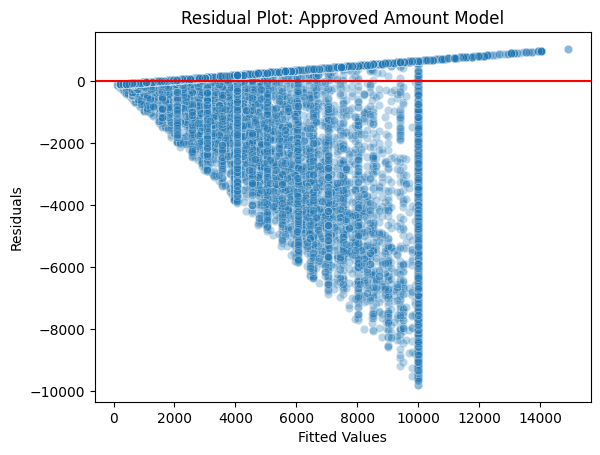

In [ ]:
# Residual plot for loan amount model
sns.scatterplot(
    x=amount_model.fittedvalues,
    y=amount_model.resid,
    alpha=0.3
)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot: Approved Loan Amount Model')
sns.despine()
plt.show()

**Diagnostic Assessment**:

- **Normality**: Both models show departures from normality in residuals (Jarque-Bera test p < 0.05). However, with n > 400,000, moderate normality violations do not materially affect coefficient estimates due to the Central Limit Theorem.

- **Heteroscedasticity**: Residual plots show modest fanning, suggesting slight heteroscedasticity. Robust standard errors would be appropriate for inference, though coefficient estimates remain unbiased.

- **Condition Number**: Large condition numbers in both models (particularly Model 1) suggest potential scaling issues due to income variable magnitude. However, this reflects data scale rather than problematic multicollinearity.

- **Multicollinearity**: Correlations among predictors are weak to moderate, indicating that predictor variables capture relatively independent information.

**Overall Assessment**: Despite diagnostic departures from classical assumptions, the models provide reliable coefficient estimates and inference due to large sample size. Findings should be interpreted with recognition of these modest violations.

### Key Modeling Insights

**Interest Pricing Mechanism**: Interest rates are primarily risk-based, determined by credit ratings, with modest income effects. This reflects a structured, transparent pricing model where borrower risk assessment (ratings) drives pricing more than demographic characteristics.

**Loan Approval Process**: Approvals closely track borrower requests with minimal adjustment, and income serves as a secondary criterion. This suggests either effective pre-screening or confidence in borrower self-assessment.

**Model Complementarity**: The two models together reveal a bifurcated decision process: quantity decisions (how much to approve) are request-driven, while price decisions (what rate to charge) are risk-driven. This separation of concerns reflects rational lending practice.

## Part 5: Synthesis and Conclusions

### 5.1 Summary of Key Findings

**Loan Distribution and Market Structure**

The Bondora platform operates primarily in Estonia and Finland, with over 409,000 loans issued. Loan amounts follow a right-skewed distribution (median ≈ 2,080 EUR), typical of consumer lending where most borrowers seek modest amounts while a significant minority requires larger financing. Loan durations cluster in the 36–60 month range, reflecting standard medium-term consumer credit products.

**Risk-Based Pricing Model**

Interest rates demonstrate a clear, monotonic relationship with credit ratings: lower-rated borrowers (higher risk) face substantially higher rates. Regression analysis confirms that credit ratings explain ~60.5% of interest rate variation, substantially more than borrower income alone. This validates Bondora's risk-based pricing framework and indicates a sophisticated assessment of borrower creditworthiness.

**Loan Approval Mechanics**

The approval process exhibits strong fidelity to borrower requests (r = 0.96 between applied and approved amounts). Borrowers receive approximately 93% of requested amounts on average, with income acting as a modest moderating factor. This suggests either effective pre-screening or confidence in borrower self-assessment.

**Demographic Patterns**

Gender differences in applied amounts are statistically insignificant, suggesting comparable access or similar financing needs. Approved amounts do differ slightly by gender, though this may reflect applicant characteristics rather than discriminatory policies, as approval adjustment gaps do not differ significantly. Income distributions across gender categories show comparable medians with right-skewness, indicating high-income earners across all gender groups.

**Portfolio Composition and Risk**

The dataset is heavily weighted toward "Repaid" loans, limiting ability to assess current default risk. Approximately 15% of borrowers meet high-risk criteria (debt-to-income > 0.35 + employment tenure < 1 year), representing a material subset requiring enhanced monitoring.

**Correlation Structure**

Weak to moderate correlations among most variables indicate that lending decisions incorporate multiple independent factors rather than being dominated by any single predictor. This low multicollinearity is favorable for statistical modeling.

### 5.2 Limitations and Qualifications

This analysis, while comprehensive, operates within important constraints that qualify the generalizability and applicability of findings.

**Data and Temporal Limitations**

The dataset's composition—heavily weighted toward "Repaid" loans—suggests it contains aged, historical loans rather than recent originations. This limits ability to assess current platform performance and forecast future outcomes. Approximately 11% of observations have missing credit ratings, excluded from rating-specific analyses. If missingness correlates with risk factors, this selective exclusion could bias estimates. Geographic focus on Estonia and Finland limits generalizability to other markets with different regulatory, economic, and cultural contexts. The analysis does not model explicit temporal trends in rates, credit conditions, or policy changes over the observation period.

**Methodological Constraints**

This is fundamentally cross-sectional analysis, examining associations at an aggregate level. Causal inferences are not possible without experimental design or instrumental variables. Unobserved confounders—such as credit history depth, employment sector, collateral, or borrower sophistication—may distort observed relationships. Regression models assume linear relationships; nonlinear or threshold effects would not be captured. Credit rating effects on interest rates may reflect omitted variables (e.g., loan purpose, term) correlated with both ratings and rates. High-risk borrower classification uses arbitrary thresholds (debt-to-income > 0.35) not validated against actual defaults.

**Data Quality Considerations**

Outliers in age and income are retained to preserve sample integrity, though they may reflect data entry errors or unusual cases. Employment duration variables are categorical rather than continuous, limiting measurement precision. Approximately 10% of observations have unknown gender status, representing either non-response or missing data that may encode meaningful information about borrower populations.

**Scope and Generalizability**

This analysis prioritizes explanatory inference over prediction. Findings describe historical associations within Bondora but should not be interpreted as predictive models for new loan decisions. Bondora's institutional context—underwriting standards, pricing algorithms, customer acquisition, regulatory environment—shapes observed patterns. Conclusions may not generalize to other peer-to-peer platforms or traditional banking. The Bondora borrower population is self-selected; patterns may not extend to borrowers using traditional credit or those excluded from formal credit markets.

### 5.3 Recommendations for Future Work

To address analytical limitations and extend insights, future research could:

1. **Temporal Cohort Analysis**: Stratify analysis by loan origination year to assess whether patterns have evolved with economic conditions and platform maturation.

2. **Default Validation**: Link risk indicators (debt-to-income, employment duration) to actual default outcomes to calibrate risk thresholds and validate classification schemes.

3. **Geographic Expansion**: Compare patterns across the full platform geography to identify region-specific lending dynamics and assess generalizability.

4. **Predictive Modeling**: Develop supervised learning models (logistic regression, ensemble methods) to predict loan performance and assess out-of-sample accuracy.

5. **Missing Data Analysis**: Conduct sensitivity analyses and multiple imputation to assess robustness to missing rating data.

6. **Nonlinear Relationships**: Employ spline-based or nonparametric methods to explore whether linear assumptions adequately capture complex relationships.

7. **Interaction Effects**: Test whether relationships depend on borrower segments (e.g., does income's effect on approvals differ by rating category?).

8. **Quasi-Experimental Design**: Exploit natural variation (policy changes, external shocks) to strengthen causal identification.

### 5.4 Dataset-Specific Research Extensions

While this analysis focused on a reduced set of variables to support exploratory and inferential objectives, the original Bondora dataset offers several opportunities for deeper investigation. The following extensions leverage available variables to address specific questions about lending dynamics that remain unexplored in this initial analysis.

**Loan Performance and Default Analysis**

The dataset contains loan status variables capturing repayment outcomes and default events. Future work could examine default-related variables and repayment timelines to assess portfolio credit risk. A time-to-event or survival analysis would provide insight into how long loans remain active before default occurs and how borrower characteristics influence default probability and timing. This analysis would directly validate the high-risk borrower classification developed in Section 2.4 by linking identified risk indicators (debt-to-income ratios, employment tenure) to actual default outcomes. Such validation would calibrate risk thresholds and refine classification schemes for enhanced predictive accuracy.

**Affordability and Debt Burden Analysis**

The dataset includes debt burden measures such as existing liabilities and detailed repayment history variables (previous loans, previous repayments). These variables enable deeper exploration of borrower affordability beyond income alone. Incorporating debt burden measures such as existing liabilities, debt-to-income ratios, and estimated free cash flow would provide a more realistic assessment of financial capacity than income alone. These variables may improve understanding of loan approval and pricing decisions by revealing whether lenders employ more sophisticated debt burden assessments than those visible in the current analysis. Multivariate analysis could decompose the relative importance of income, debt obligations, and employment stability in determining loan outcomes.

**Borrower Experience and Repeat Lending**

The dataset captures borrower credit history through variables including the number of previous loans and cumulative amount of previous borrowing. Future analysis could segment first-time borrowers and repeat borrowers based on previous loan and repayment behavior. This comparative analysis would allow assessment of lending outcomes across experience levels, revealing whether repeat borrowing is associated with improved loan performance, lower default rates, or more favorable pricing. Additionally, this analysis would help identify whether the platform implements progressive lending (increasing amounts for reliable borrowers) or whether repeat borrowers face tightened underwriting criteria.

**Integration and Scope**

These extensions were intentionally deferred from the current analysis to maintain manageable scope and focus on applying core data analytics techniques. The foundational understanding developed in this project—particularly regarding risk assessment mechanisms, approval processes, and demographic patterns—provides essential context for these more specialized investigations. Future work building on this foundation would substantially enhance understanding of peer-to-peer lending market mechanics and validate the analytical frameworks established here.

## Conclusion

This exploratory data analysis provides a structured, evidence-based understanding of peer-to-peer lending dynamics within the Bondora platform. The analysis confirms that lending decisions are multifactorial, with risk-based pricing (via credit ratings) driving interest rates and request-driven approval determining loan quantities. The absence of strong gender-based disparities in approval outcomes and adjustment gaps suggests relatively uniform application of lending criteria.

The work demonstrates competency across the data analytics lifecycle: cleaning and preparation, exploratory visualization, hypothesis testing, and explanatory modeling. While limitations regarding temporal scope, geographic coverage, and causal inference are acknowledged, the findings provide valuable baseline understanding of peer-to-peer lending market mechanics and borrower segmentation.

Practitioners and researchers can leverage these insights to understand lending market structure, inform pricing decisions, and identify areas for enhanced risk management. The identified limitations provide clear pathways for future research to deepen analytical rigor and extend generalizability.